In [3]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
from matplotlib.patches import Rectangle
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import colormaps
from matplotlib.patches import Rectangle
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible with tight_layout")
%matplotlib inline

In [4]:
## reading in OLR information

path = '/home/annierosen16/data/era5sgp/era5_sl_olr_sgp'

olr_files = sorted(glob.glob(f"{path}/*.nc"))

olr = xr.open_mfdataset(olr_files, combine="by_coords")

olr['valid_time'] = olr['valid_time'] - pd.Timedelta(hours=6)

olr = olr.rename({"valid_time": "time"})

timestep_seconds = 3600  # at a 1 hour frequency

olr['olr'] = -1 * olr['ttr'] / timestep_seconds  # Now in W/m²

olr = olr.where(olr['time.month'] != 4, drop=True)

In [5]:
## reading in APEs information

with open('/home/annierosen16/master.pkl', 'rb') as f:
    
    master = pickle.load(f)
    
master['date'] = pd.to_datetime(master['date']).dt.date

#### composite OLR for dry apes 

In [7]:
olr_df = olr['olr'].to_dataframe().reset_index()

olr_df['date'] = pd.to_datetime(olr_df['time']).dt.date

olr_grouped = olr_df.groupby(['date', 'latitude', 'longitude'])['olr'].apply(lambda x: x.values).reset_index()

master_with_olr = master.merge(olr_grouped, on=['date', 'latitude', 'longitude'], how='left')

In [8]:
dryapes = master_with_olr[master_with_olr['dryape']==True].reset_index(drop=True)

wetapes = master_with_olr[master_with_olr['wetape']==True].reset_index(drop=True)

no_ape = master_with_olr[master_with_olr['APE']==False].reset_index(drop=True)

no_ape = no_ape[no_ape['daily_precip'].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) == 24)]

dry_olr_array = np.stack(dryapes['olr'].values)

wet_olr_array = np.stack(wetapes['olr'].values)

dry_olr_composite = dry_olr_array.mean(axis=0)

wet_olr_composite = wet_olr_array.mean(axis=0)

no_ape_olr_array = np.stack(no_ape['olr'].values)

no_ape_olr_composite = no_ape_olr_array.mean(axis=0)

In [9]:
master_with_olr = master_with_olr[master_with_olr['daily_precip'].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) == 24)].reset_index(drop=True)

master_with_olr['daily_precip_sum'] = master_with_olr['daily_precip'].apply(lambda x: np.sum(x))

no_precip_rows = master_with_olr[master_with_olr['daily_precip_sum'] == 0].reset_index(drop=True)

no_precip_olr_array = np.stack(no_precip_rows['olr'].values)

no_precip_olr_composite = no_precip_olr_array.mean(axis=0)

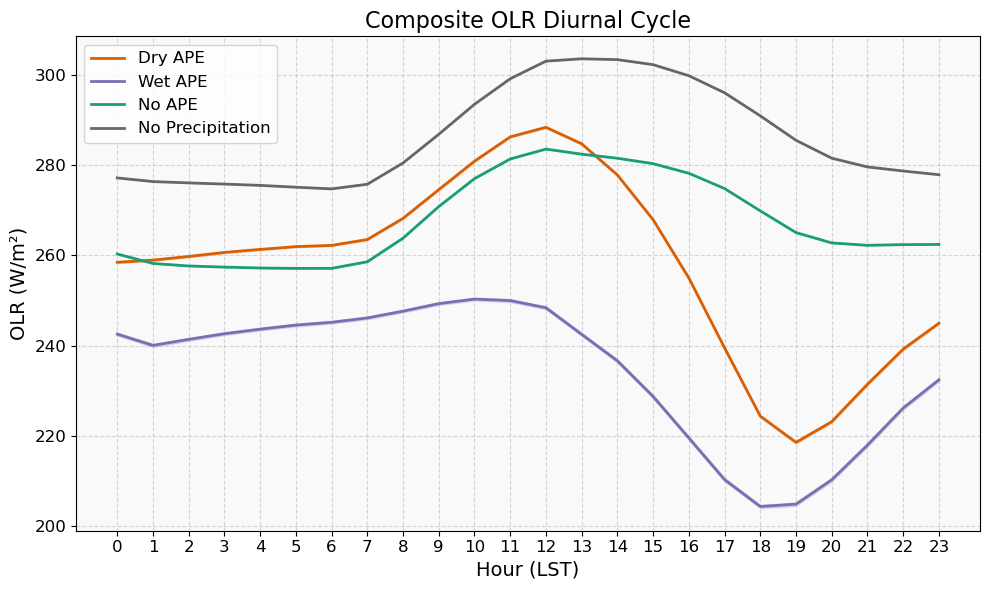

In [10]:
# Compute standard error of the mean (SEM)
dry_olr_sem = dry_olr_array.std(axis=0) / np.sqrt(dry_olr_array.shape[0])

wet_olr_sem = wet_olr_array.std(axis=0) / np.sqrt(wet_olr_array.shape[0])

no_ape_olr_sem = no_ape_olr_array.std(axis=0) / np.sqrt(no_ape_olr_array.shape[0])

# Compute the 95% confidence interval (1.96 * SEM)

dry_olr_ci = 1.96 * dry_olr_sem

wet_olr_ci = 1.96 * wet_olr_sem

no_ape_olr_ci = 1.96 * no_ape_olr_sem

# Time axis
hours = list(range(24))

# Colors (muted palette)
dry_color = '#d95f02'      # Muted orange

wet_color = '#7570b3'      # Muted purple

noape_color = '#1b9e77'    # Muted teal

noprecip_color = '#666666' # Muted gray

test_case_color = '#e7298a'  # Muted magenta/pink

# Create the plot
plt.figure(figsize=(10, 6))

# Plot means with solid lines
plt.plot(hours, dry_olr_composite, label='Dry APE', color=dry_color, lw=2)

plt.plot(hours, wet_olr_composite, label='Wet APE', color=wet_color, lw=2)

plt.plot(hours, no_ape_olr_composite, label='No APE', color=noape_color, lw=2)

plt.plot(hours, no_precip_olr_composite, label='No Precipitation', color=noprecip_color, lw=2)

# plt.plot(hours, wetapes['olr'].iloc[61040], label='test case', color=test_case_color, lw=2)

# Add shaded 95% confidence intervals

plt.fill_between(hours, dry_olr_composite - dry_olr_ci, dry_olr_composite + dry_olr_ci,
                 color=dry_color, alpha=0.2)

plt.fill_between(hours, wet_olr_composite - wet_olr_ci, wet_olr_composite + wet_olr_ci,
                 color=wet_color, alpha=0.2)

plt.fill_between(hours, no_ape_olr_composite - no_ape_olr_ci, no_ape_olr_composite + no_ape_olr_ci,
                 color=noape_color, alpha=0.2)

# Formatting
plt.xticks(hours, fontsize=12)

plt.yticks(fontsize=12)

plt.xlabel('Hour (LST)', fontsize=14)

plt.ylabel('OLR (W/m²)', fontsize=14)

plt.title('Composite OLR Diurnal Cycle', fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(loc='upper left', fontsize=12)

plt.gca().set_facecolor('#f9f9f9')

plt.tight_layout()

plt.show()

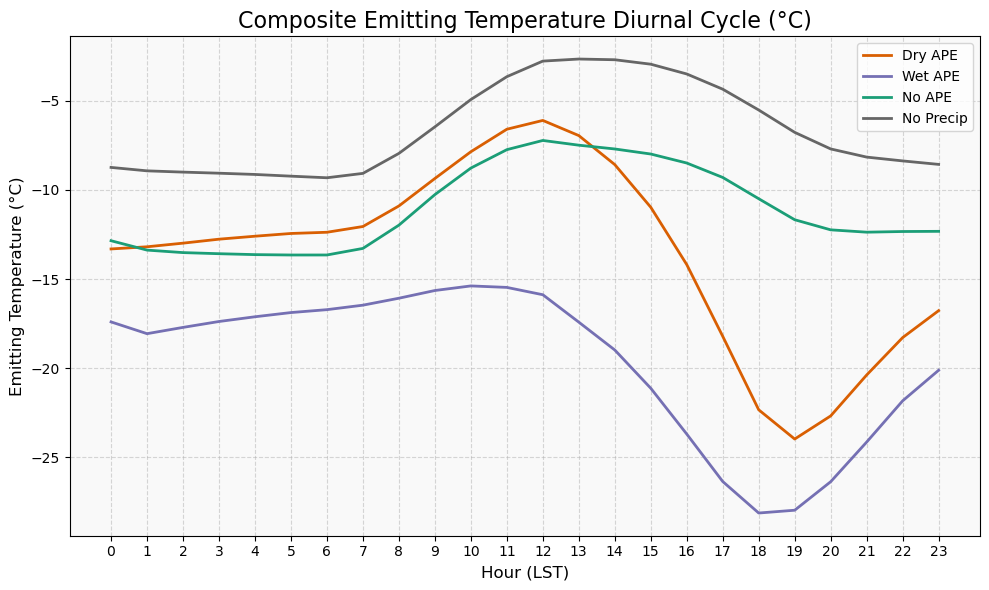

In [11]:
sigma = 5.67e-8

hours = list(range(24))

# Calculate emitting temperatures (in Kelvin)
emitting_dryape_temps = (dry_olr_composite / sigma) ** 0.25

emitting_wetape_temps = (wet_olr_composite / sigma) ** 0.25

emitting_noape_temps = (no_ape_olr_composite / sigma) ** 0.25

emitting_no_precip_temps = (no_precip_olr_composite / sigma) ** 0.25

# Optional: convert to Celsius
dry_C = emitting_dryape_temps - 273.15

wet_C = emitting_wetape_temps - 273.15

noape_C = emitting_noape_temps - 273.15

noprecip_C = emitting_no_precip_temps - 273.15

dry_F = (emitting_dryape_temps - 273.15) * 9/5 + 32

wet_F = (emitting_wetape_temps - 273.15) * 9/5 + 32

noape_F = (emitting_noape_temps - 273.15) * 9/5 + 32

noprecip_F = (emitting_no_precip_temps - 273.15) * 9/5 + 32

# Plot with muted colors
plt.figure(figsize=(10, 6))

plt.plot(hours, dry_C, label='Dry APE', color='#d95f02', linewidth=2)       # Muted orange

plt.plot(hours, wet_C, label='Wet APE', color='#7570b3', linewidth=2)       # Muted purple

plt.plot(hours, noape_C, label='No APE', color='#1b9e77', linewidth=2)      # Muted teal

plt.plot(hours, noprecip_C, label='No Precip', color='#666666', linewidth=2) # Muted gray

# Formatting
plt.xticks(hours)

plt.xlabel('Hour (LST)', fontsize=12)

plt.ylabel('Emitting Temperature (°C)', fontsize=12)

plt.title('Composite Emitting Temperature Diurnal Cycle (°C)', fontsize=16)

plt.legend()

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Optional: Add light background
plt.gca().set_facecolor('#f9f9f9')

plt.show()


In [14]:
# to load into era4_cloud_cover

mini_master_with_olr = master_with_olr[['date', 'latitude', 'longitude', 'olr']]

with open('mini_master_with_olr.pkl', 'wb') as f:
    
    pickle.dump(mini_master_with_olr, f)